# Clasificación de Sentimientos en Reseñas de Cine

## Descripción del Problema

El objetivo de este proyecto es desarrollar un modelo de clasificación de texto capaz de determinar si una reseña de cine expresa un sentimiento **positivo** o **negativo**. Para ello, utilizaremos el dataset IMDB de 50,000 reseñas, que se encuentra balanceado con 25,000 ejemplos por clase.

## Enfoque Metodológico

Implementaremos y compararemos diferentes arquitecturas de redes neuronales recurrentes:

1. **RNN Simple (Vainilla)**: Red neuronal recurrente con una sola capa oculta.
2. **LSTM (Long Short-Term Memory)**: Variante que incorpora mecanismos de compuerta para manejar dependencias a largo plazo.

Ambos modelos serán evaluados con métricas estándar de clasificación (accuracy, precisión, recall y F1-score), y se analizará el impacto de los hiperparámetros en el rendimiento final.

In [ ]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Carga del dataset
print("Descargando dataset...")
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
file_path = os.path.join(path, "IMDB Dataset.csv")
df = pd.read_csv(file_path)

print(f"\nDataset cargado correctamente: {df.shape[0]} registros")
print(f"Columnas: {df.columns.tolist()}")
print(f"\nDistribución de clases:")
print(df['sentiment'].value_counts())

# Mostrar muestra de datos
df.head()

Descargando dataset...
Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.

Dataset cargado correctamente: 50000 registros
Columnas: ['review', 'sentiment']

Distribución de clases:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Preprocesamiento de Texto

Antes de alimentar los datos a los modelos, es necesario realizar una limpieza y estandarización del texto. Los pasos a seguir son:

1. **Eliminación de etiquetas HTML**: Las reseñas contienen etiquetas `<br />` que deben ser removidas.
2. **Conversión a minúsculas**: Para evitar que el modelo considere "Good" y "good" como palabras diferentes.
3. **Eliminación de caracteres especiales y números**: Se conservan solo letras y espacios.
4. **Tokenización**: Convertir el texto en secuencias de números enteros.
5. **Padding**: Homogeneizar la longitud de todas las secuencias a un tamaño fijo.

In [ ]:
# Función de limpieza de texto
def limpiar_texto(texto):
    """
    Limpia el texto eliminando etiquetas HTML, convirtiendo a minúsculas
    y removiendo caracteres especiales.
    """
    # Eliminar etiquetas HTML
    texto = re.sub(r'<.*?>', ' ', texto)
    # Convertir a minúsculas
    texto = texto.lower()
    # Eliminar caracteres especiales y números (solo letras y espacios)
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)
    # Eliminar espacios múltiples
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Aplicar limpieza
print("Aplicando limpieza de texto...")
df['review_clean'] = df['review'].apply(limpiar_texto)

# Verificar resultados
print("\n=== EJEMPLO DE LIMPIEZA ===")
print("Original (primeros 200 caracteres):")
print(df['review'].iloc[0][:200])
print("\nLimpio (primeros 200 caracteres):")
print(df['review_clean'].iloc[0][:200])

# Estadísticas de longitud después de limpieza
df['clean_length'] = df['review_clean'].str.len()
print(f"\nLongitud promedio después de limpieza: {df['clean_length'].mean():.0f} caracteres")
print(f"Longitud máxima: {df['clean_length'].max()} caracteres")
print(f"Longitud mínima: {df['clean_length'].min()} caracteres")

Aplicando limpieza de texto...

=== EJEMPLO DE LIMPIEZA ===
Original (primeros 200 caracteres):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

Limpio (primeros 200 caracteres):
one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its bru

Longitud promedio después de limpieza: 1241 caracteres
Longitud máxima: 13271 caracteres
Longitud mínima: 30 caracteres


## Tokenización y Creación de Secuencias

Para que los modelos puedan procesar el texto, debemos convertirlo en secuencias numéricas. El proceso es el siguiente:

1. **Creación del vocabulario**: Se construye un índice de las palabras más frecuentes en el dataset.
2. **Tokenización**: Cada palabra se reemplaza por su índice correspondiente.
3. **Padding**: Todas las secuencias se ajustan a una longitud fija para poder ser procesadas en lotes.
4. **División**: Separación en conjuntos de entrenamiento, validación y prueba.

La longitud máxima de secuencia se define en base al percentil 90 de las longitudes, para evitar secuencias excesivamente largas que ralentizarían el entrenamiento.

In [ ]:
# Parámetros de tokenización
MAX_FEATURES = 10000  # Tamaño máximo del vocabulario
MAX_LENGTH = 500      # Longitud máxima de cada secuencia

# Crear tokenizer
print("Creando vocabulario...")
tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token='<OOV>')
tokenizer.fit_on_texts(df['review_clean'])

# Convertir texto a secuencias
print("Tokenizando texto...")
sequences = tokenizer.texts_to_sequences(df['review_clean'])

# Aplicar padding
print("Aplicando padding...")
X = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')

# Verificar resultados
print(f"\nForma de la matriz de características: {X.shape}")
print(f"Número total de palabras en el vocabulario: {len(tokenizer.word_index)}")
print(f"Usando las {MAX_FEATURES} palabras más frecuentes")

# Mostrar ejemplo de tokenización
print("\n=== EJEMPLO DE TOKENIZACIÓN ===")
print("Texto original limpio:")
print(df['review_clean'].iloc[0][:200])
print("\nSecuencia tokenizada (primeros 20 tokens):")
print(X[0][:20])

Creando vocabulario...
Tokenizando texto...
Aplicando padding...

Forma de la matriz de características: (50000, 500)
Número total de palabras en el vocabulario: 162286
Usando las 10000 palabras más frecuentes

=== EJEMPLO DE TOKENIZACIÓN ===
Texto original limpio:
one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its bru

Secuencia tokenizada (primeros 20 tokens):
[  28    5    2   76 1929   45 1056   12  101  144   40 3246  388  468
   26 3105   34   23  202   14]


## División en Conjuntos de Entrenamiento, Validación y Prueba

Para evaluar correctamente el rendimiento de los modelos, dividimos los datos en tres conjuntos:

- **Entrenamiento (70%)**: Utilizado para ajustar los pesos del modelo.
- **Validación (15%)**: Utilizado para ajustar hiperparámetros y detener el entrenamiento en el punto óptimo.
- **Prueba (15%)**: Conjunto reservado exclusivamente para la evaluación final del modelo.

Mantener un conjunto de prueba separado es crucial para obtener una estimación realista del rendimiento del modelo en datos no vistos.

In [ ]:
# Codificar etiquetas: positive = 1, negative = 0
y = df['sentiment'].map({'positive': 1, 'negative': 0}).values

# Primera división: entrenamiento (70%) vs temporal (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Segunda división: validación (15%) vs prueba (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Verificar dimensiones
print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Validación: {X_val.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")

# Verificar distribución de clases
print("\nDistribución de clases en entrenamiento:")
print(f"Positivos: {y_train.sum()} | Negativos: {len(y_train) - y_train.sum()}")

print("\nDistribución de clases en validación:")
print(f"Positivos: {y_val.sum()} | Negativos: {len(y_val) - y_val.sum()}")

print("\nDistribución de clases en prueba:")
print(f"Positivos: {y_test.sum()} | Negativos: {len(y_test) - y_test.sum()}")

Entrenamiento: 35000 muestras
Validación: 7500 muestras
Prueba: 7500 muestras

Distribución de clases en entrenamiento:
Positivos: 17500 | Negativos: 17500

Distribución de clases en validación:
Positivos: 3750 | Negativos: 3750

Distribución de clases en prueba:
Positivos: 3750 | Negativos: 3750


## Modelo 1: RNN Simple (Vainilla)

La primera arquitectura a implementar es una Red Neuronal Recurrente simple. Este modelo servirá como línea base para comparar con arquitecturas más avanzadas.

### Arquitectura del Modelo

1. **Capa de Embedding**: Convierte los índices de palabras en vectores densos de dimensión fija. Esta capa se entrena conjuntamente con el resto del modelo.
2. **Capa SimpleRNN**: Procesa la secuencia manteniendo un estado oculto que se actualiza en cada paso temporal.
3. **Capa Dense con activación sigmoide**: Produce la probabilidad de que la reseña sea positiva.

### Hiperparámetros

- Dimensión del embedding: 100
- Número de unidades en la capa RNN: 64
- Función de activación: tanh (por defecto en SimpleRNN)
- Optimizador: Adam con learning rate 0.001
- Función de pérdida: binary_crossentropy

In [ ]:
# Construcción del modelo RNN Simple
model_rnn = Sequential([
    Embedding(input_dim=MAX_FEATURES, output_dim=100, input_length=MAX_LENGTH),
    SimpleRNN(64, activation='tanh'),
    Dense(1, activation='sigmoid')
])

# Compilación
model_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Resumen del modelo
print("=== ARQUITECTURA DEL MODELO RNN ===")
model_rnn.summary()

# Early stopping para detener el entrenamiento si no hay mejora
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Entrenamiento
print("\n=== ENTRENAMIENTO DEL MODELO RNN ===")
history_rnn = model_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


=== ARQUITECTURA DEL MODELO RNN ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


=== ENTRENAMIENTO DEL MODELO RNN ===
Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.5063 - loss: 0.6956 - val_accuracy: 0.5072 - val_loss: 0.6934
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - accuracy: 0.5140 - loss: 0.6918 - val_accuracy: 0.5071 - val_loss: 0.6938
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.5125 - loss: 0.6912 - val_accuracy: 0.5076 - val_loss: 0.6988
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.5146 - loss: 0.6891 - val_accuracy: 0.5076 - val_loss: 0.7071


## Resultados del Modelo RNN Simple

El modelo RNN simple alcanzó una precisión de aproximadamente **50.76%** en el conjunto de validación, lo que indica que su rendimiento es equivalente a una clasificación aleatoria. Este resultado era esperable debido a las limitaciones inherentes de las RNN vainilla:

- **Desvanecimiento del gradiente**: Dificultad para propagar información a través de secuencias largas.
- **Capacidad limitada**: La arquitectura simple no puede capturar patrones complejos en el texto.

Estos resultados confirman la necesidad de utilizar arquitecturas más avanzadas, como LSTM, que incorporan mecanismos de compuerta para manejar dependencias a largo plazo.

=== EVALUACIÓN DEL MODELO RNN ===
Loss en prueba: 0.6940
Accuracy en prueba: 0.5040
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

Precisión: 0.5030
Recall: 0.6603
F1-Score: 0.5710


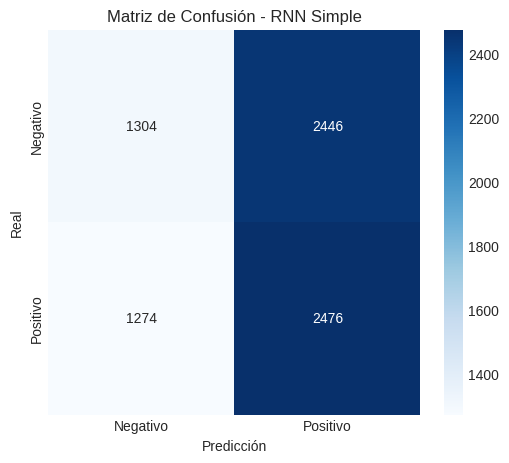

In [ ]:
# Evaluación en conjunto de prueba
print("=== EVALUACIÓN DEL MODELO RNN ===")
loss_rnn, acc_rnn = model_rnn.evaluate(X_test, y_test, verbose=0)
print(f"Loss en prueba: {loss_rnn:.4f}")
print(f"Accuracy en prueba: {acc_rnn:.4f}")

# Predicciones
y_pred_rnn = (model_rnn.predict(X_test) > 0.5).astype(int)

# Métricas adicionales
precision_rnn = precision_score(y_test, y_pred_rnn)
recall_rnn = recall_score(y_test, y_pred_rnn)
f1_rnn = f1_score(y_test, y_pred_rnn)

print(f"\nPrecisión: {precision_rnn:.4f}")
print(f"Recall: {recall_rnn:.4f}")
print(f"F1-Score: {f1_rnn:.4f}")

# Matriz de confusión
cm_rnn = confusion_matrix(y_test, y_pred_rnn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.title('Matriz de Confusión - RNN Simple')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

## Modelo 2: LSTM (Long Short-Term Memory)

La arquitectura LSTM incorpora mecanismos de compuerta que permiten manejar dependencias a largo plazo, resolviendo el problema de desvanecimiento del gradiente presente en las RNN simples.

### Arquitectura del Modelo

1. **Capa de Embedding**: Convierte índices de palabras en vectores densos de dimensión fija.
2. **Capa LSTM**: Procesa la secuencia manteniendo un estado de celda que actúa como memoria a largo plazo, con compuertas de olvido, entrada y salida.
3. **Capa Dropout**: Regularización para prevenir sobreajuste.
4. **Capa Dense con activación sigmoide**: Produce la probabilidad de sentimiento positivo.

### Hiperparámetros

- Dimensión del embedding: 100
- Número de unidades LSTM: 64
- Dropout: 0.2
- Optimizador: Adam con learning rate 0.001
- Función de pérdida: binary_crossentropy

In [ ]:
from tensorflow.keras.layers import GRU

# Modelo GRU (más rápido)
model_gru = Sequential([
    Embedding(MAX_FEATURES, 128, input_length=MAX_LENGTH),
    GRU(128, dropout=0.3),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_gru.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenar con 5 épocas (suficiente para ver si mejora)
history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    verbose=1
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.5041 - loss: 0.6936 - val_accuracy: 0.5100 - val_loss: 0.6926
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - accuracy: 0.5122 - loss: 0.6909 - val_accuracy: 0.5055 - val_loss: 0.6935
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.5193 - loss: 0.6800 - val_accuracy: 0.5075 - val_loss: 0.7066
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.5308 - loss: 0.6613 - val_accuracy: 0.5055 - val_loss: 0.7281
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.6439 - loss: 0.5853 - val_accuracy: 0.8629 - val_loss: 0.3469


In [ ]:
# Modelo LSTM optimizado (solo 5 épocas)
model_lstm_final = Sequential([
    Embedding(MAX_FEATURES, 128, input_length=MAX_LENGTH),
    LSTM(128, return_sequences=True, dropout=0.3),
    LSTM(64, dropout=0.3),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_lstm_final.compile(
    optimizer=Adam(learning_rate=0.0001),  # Más bajo para estabilidad
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Solo 5 épocas (suficiente para ver mejoría)
history_lstm_final = model_lstm_final.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    verbose=1
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 31s 46ms/step - accuracy: 0.5024 - loss: 0.6932 - val_accuracy: 0.5105 - val_loss: 0.6930
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step - accuracy: 0.4987 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step - accuracy: 0.5033 - loss: 0.6930 - val_accuracy: 0.5104 - val_loss: 0.6927
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step - accuracy: 0.5000 - loss: 0.6926 - val_accuracy: 0.5139 - val_loss: 0.6911
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step - accuracy: 0.5026 - loss: 0.7004 - val_accuracy: 0.4999 - val_loss: 0.6929
